# ASG Airlines: Data Engineering Case Study

**Objective:** Ingest operational flight data, clean data quality issues, protect passenger PII, and build a reliable dataset for reporting and KPIs.

## Phase 1: Data Ingestion & Initial Inspection

### 1.1 Imports
Importing pandas, hashlib (for PII hashing), matplotlib/seaborn (for charts), and os.

In [3]:
import pandas as pd
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns
import os


### 1.2 Loading Datasets
Loading all 4 sheets from the Excel file (`flights`, `bookings`, `passengers`, `payments`) into pandas DataFrames.

In [4]:
file_path = "/home/fallen/git/Airlines Use Case/UseCase - Airlines.xlsx"
df_flights = pd.read_excel(file_path, sheet_name = 'flights')
df_bookings = pd.read_excel(file_path, sheet_name = 'bookings')
df_passengers = pd.read_excel(file_path, sheet_name = 'passengers')
df_payments = pd.read_excel(file_path, sheet_name = 'payments')

### 1.3 Checking Shapes and Data Types
Checking rows, columns, and data types for each table to see how the raw data is formatted.

In [3]:
print("df_flights info:")
df_flights.info()
print("\ndf_bookings info:")
df_bookings.info()
print("\ndf_passengers info:")
df_passengers.info()
print("\ndf_payments info:")
df_payments.info()

df_flights info:
<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       1020 non-null   str           
 1   airline         979 non-null    str           
 2   source          1020 non-null   str           
 3   destination     1020 non-null   str           
 4   departure_time  1020 non-null   datetime64[us]
 5   arrival_time    1020 non-null   datetime64[us]
 6   duration        1020 non-null   object        
dtypes: datetime64[us](2), object(1), str(4)
memory usage: 55.9+ KB

df_bookings info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   booking_id               1000 non-null   str           
 1   passenger_id             1000 non-null   str       

### 1.4 Previewing Data
Printing the first 5 rows of each sheet to get a quick visual look at the raw data.

In [4]:
print("Flights data:\n")
display(df_flights.head())
print("\nBookings data:\n")
display(df_bookings.head())
print("\nPassengers data:\n")
display(df_passengers.head())
print("\nPayments data:\n")
display(df_payments.head())


Flights data:



,flight_id,airline,source,destination,departure_time,arrival_time,duration
0,SJ010,SpiceJet,CCU,MAA,2026-04-20 23:38:41.701,2026-04-21 02:32:41.701,02:54:00
1,AI155,Air India,BOM,CCU,2026-04-20 23:35:41.703,2026-04-21 01:23:41.703,01:48:00
2,UK094,Vistara,BOM,CCU,2026-04-20 23:26:41.702,2026-04-21 01:11:41.702,01:45:00
3,AI245,Air India,BOM,CCU,2026-04-20 23:07:41.704,2026-04-21 01:43:41.704,02:36:00
4,AI192,Air India,MAA,BOM,2026-04-20 23:05:41.703,2026-04-21 04:04:41.703,04:59:00



Bookings data:



,booking_id,passenger_id,flight_id,booking_date,status,passport_number,seat_number,emergency_contact_name,emergency_contact_phone
0,B1000,P1591,AI192,2025-06-14 11:37:36.951,CANCELLED,P1945887,3D,Isaac Bakshi,+91-6478475128
1,B1001,P1803,6F026,2025-11-02 11:37:36.951,CANCELLED,L3482012,18A,Anvi Konda,+91-6647078662
2,B1002,P1083,SJ010,2025-08-25 11:37:36.951,CANCELLED,G8507659,30C,Udant Dewan,+91-8405938220
3,B1003,P1364,AI069,2025-12-30 11:37:36.951,CONFIRMED,M0891776,33A,Harsh Chahal,+91-6264636839
4,B1004,P1885,UK003,2025-10-02 11:37:36.951,PENDING,N5742231,25C,Pahal Balay,+91-9336478266



Passengers data:



,passenger_id,first_name,last_name,age,gender,email,phone,aadhaar_id,date_of_birth
0,P1000,Vivaan,Chatterjee,52,F,vivaan.chatterjee@gmail.com,+91-6896233790,433218196001,1974-04-08
1,P1001,Krishna,Reddy,15,M,krishna.reddy@hotmail.com,+91-6702632297,386379402654,2011-03-07
2,P1002,Myra,Naidu,72,M,myra.naidu@outlook.com,+91-6199585092,615594078161,1954-09-10
3,P1003,Myra,Mishra,61,F,myra.mishra@hotmail.com,+91-8719927151,310341316475,1965-03-12
4,P1004,Saanvi,Banerjee,21,M,saanvi.banerjee@outlook.com,+91-7819595113,419283276483,2005-11-11



Payments data:



,payment_id,booking_id,amount,payment_method
0,PAY1000,B1116,9883.49,NETBANKING
1,PAY1001,B1738,8457.96,NETBANKING
2,PAY1002,B1873,6495.37,UPI
3,PAY1003,B1914,5079.38,NETBANKING
4,PAY1004,B1967,12518.31,CARD


### 1.5 Initial Data Quality Check (Nulls & Duplicates)
Checking for missing values and completely duplicated rows across all 4 tables.

In [5]:
print("null values in flights:\n", df_flights.isnull().sum(), "\n\nDuplicates in flights:", df_flights.duplicated().sum())
print("\nnull values in bookings:\n", df_bookings.isnull().sum(), "\n\nDuplicates in bookings:\n", df_bookings.duplicated().sum())
print("\nnull values in passengers:\n", df_passengers.isnull().sum(), "\n\nDuplicates in passengers:\n", df_passengers.duplicated().sum())
print("\nnull values in payments:\n", df_payments.isnull().sum(), "\n\nDuplicates in payments:\n", df_payments.duplicated().sum())

null values in flights:
 flight_id          0
airline           41
source             0
destination        0
departure_time     0
arrival_time       0
duration           0
dtype: int64 

Duplicates in flights: 15

null values in bookings:
 booking_id                  0
passenger_id                0
flight_id                   0
booking_date                0
status                     45
passport_number             0
seat_number                 0
emergency_contact_name      0
emergency_contact_phone     0
dtype: int64 

Duplicates in bookings:
 0

null values in passengers:
 passenger_id      0
first_name        0
last_name        10
age               0
gender            0
email             0
phone             0
aadhaar_id        0
date_of_birth     0
dtype: int64 

Duplicates in passengers:
 0

null values in payments:
 payment_id         0
booking_id         0
amount            48
payment_method     0
dtype: int64 

Duplicates in payments:
 0


## Phase 2: Data Cleaning & Transformation

From the initial inspection, we identified several data quality issues:
- 41 missing and 31 'UNKNOWN' airline names in `flights`.
- Duplicate flight IDs and invalid/negative durations.
- Duplicate passenger IDs with missing last names.
- Missing and 'INVALID' statuses in `bookings`.
- Missing and 'INVALID' text values in payment amounts.
- Sensitive PII (Aadhaar, Passport, Phone, Email, DOB) stored as plain text.

### 2.1 Fixing Missing and UNKNOWN Airline Names


In [5]:
flight_names = {
    "AI": "Air India",
    "6F": "IndiGo",
    "SJ": "SpiceJet",
    "UK": "Vistara"
}

def get_flight_name(flight_code):
    x = flight_code[0:2]
    return flight_names[x]

# adding flight name where airline is null or unknown
for index, row in df_flights.iterrows():
    if pd.isnull(row['airline']) or row['airline'] == "UNKNOWN":
        df_flights.at[index, 'airline'] = get_flight_name(row['flight_id'])
df_flights.isnull().sum()

flight_id         0
airline           0
source            0
destination       0
departure_time    0
arrival_time      0
duration          0
dtype: int64

### 2.2 Removing Duplicate Flights & Calculating Duration
- Dropping duplicate `flight_id` records by keeping the first occurrence.
- Calculating `duration_minutes` from arrival and departure times (this handles cross-day/overnight flights properly since datetimes contain the full date).
- Dropping the original `duration` column since it only had raw Excel formulas (`=F2-E2`).
- Checking for anomalies: I found one record with negative duration (-1140 min), which is an error, so its filtered out.

In [6]:
print("Before removing duplicates shape :", df_flights.shape)
df_flights = df_flights.drop_duplicates(subset='flight_id', keep='first')
print("After removing duplicates shape :", df_flights.shape)

df_flights['duration_minutes'] = (df_flights['arrival_time'] - df_flights['departure_time']).dt.total_seconds() / 60
df_flights = df_flights.drop('duration', axis=1)

print("\nFlights data after removing duplicates and adding duration_minutes:")
display(df_flights.head())

print("Checking duration description for anomalies in flight data:")
print(df_flights['duration_minutes'].describe())

print("\nChecking for flights with duration <= 0:")
display(df_flights[df_flights['duration_minutes'] <= 0])

df_flights = df_flights[df_flights['duration_minutes'] > 0]
print("Checking duration description for anomalies in flight data:")
print(df_flights['duration_minutes'].describe())

Before removing duplicates shape : (1020, 7)
After removing duplicates shape : (1004, 7)

Flights data after removing duplicates and adding duration_minutes:


,flight_id,airline,source,destination,departure_time,arrival_time,duration_minutes
0,SJ010,SpiceJet,CCU,MAA,2026-04-20 23:38:41.701,2026-04-21 02:32:41.701,174.0
1,AI155,Air India,BOM,CCU,2026-04-20 23:35:41.703,2026-04-21 01:23:41.703,108.0
2,UK094,Vistara,BOM,CCU,2026-04-20 23:26:41.702,2026-04-21 01:11:41.702,105.0
3,AI245,Air India,BOM,CCU,2026-04-20 23:07:41.704,2026-04-21 01:43:41.704,156.0
4,AI192,Air India,MAA,BOM,2026-04-20 23:05:41.703,2026-04-21 04:04:41.703,299.0


Checking duration description for anomalies in flight data:
count    1004.000000
mean      163.316867
std        87.557585
min     -1140.000000
25%        99.000000
50%       166.000000
75%       233.250000
max       300.000000
Name: duration_minutes, dtype: float64

Checking for flights with duration <= 0:


,flight_id,airline,source,destination,departure_time,arrival_time,duration_minutes
355,SJ192,SpiceJet,HYD,BOM,2026-04-19 18:45:42,2026-04-18 23:45:42,-1140.0


Checking duration description for anomalies in flight data:
count    1003.000000
mean      164.616285
std        77.311365
min        30.000000
25%        99.000000
50%       166.000000
75%       233.500000
max       300.000000
Name: duration_minutes, dtype: float64


### 2.3 Handling Duplicate Passengers
Some passenger IDs appear more than once (e.g. where full name was merged into `first_name` and `last_name` was left null).
We sort by `last_name` so complete records come first, then drop duplicates by `passenger_id`.

In [7]:
print("passengers data after removing duplicates:", df_passengers.shape)
df_passengers = df_passengers.sort_values('last_name', na_position='last')
df_passengers = df_passengers.drop_duplicates(subset='passenger_id', keep='first')
print("passengers data after removing duplicates:", df_passengers.shape)

passengers data after removing duplicates: (1039, 9)
passengers data after removing duplicates: (1000, 9)


### 2.4 Standardizing Booking Status
- Replacing 'INVALID' status with 'CANCELLED' (assuming these bookings failed validation).
- Filling any remaining null statuses with 'UNKNOWN'.

In [8]:
df_bookings['status'] = df_bookings['status'].fillna("UNKNOWN")
df_bookings.replace(to_replace = "INVALID", value = "CANCELLED", inplace = True)
df_bookings['status'].value_counts()

status
CANCELLED    344
CONFIRMED    320
PENDING      291
UNKNOWN       45
Name: count, dtype: int64

### 2.5 Handling Missing and Invalid Payment Amounts
The `amount` column had both null values and the text 'INVALID'.
I converted strings to NaN. Instead of guessing or filling fake money values, I also add a boolean column `is_amount_missing` to flag them.

In [9]:
df_payments['amount'] = pd.to_numeric(df_payments['amount'], errors='coerce')
df_payments['is_amount_missing'] = df_payments['amount'].isnull()
display(df_payments[df_payments['is_amount_missing'] == True])

,payment_id,booking_id,amount,payment_method,is_amount_missing
18,PAY1018,B1798,NaN,CARD,True
19,PAY1019,B1875,NaN,NETBANKING,True
24,PAY1024,B1523,NaN,CARD,True
26,PAY1026,B1120,NaN,CARD,True
33,PAY1033,B1012,NaN,CARD,True
...,...,...,...,...,...
925,PAY1925,B1872,NaN,NETBANKING,True
949,PAY1949,B1376,NaN,UPI,True
961,PAY1961,B1585,NaN,UPI,True
981,PAY1981,B1324,NaN,CARD,True


### 2.6 Masking Sensitive Data (PII Protection)
To protect passenger personal information (DPDP / privacy compliance):
- **Aadhaar ID & Passport Number:** Hashed using SHA-256 (one-way hash).
- **Email:** Showing first 2 letters + `*****@domain`.
- **Phone & Emergency Contact:** Masking all digits except the last 4.
- **Date of Birth:** Storing only the birth year.

In [10]:
def hash_sha256(value):
    if pd.isna(value):
        return value
    return hashlib.sha256(str(value).encode()).hexdigest()

def mask_email(email):
    if pd.isna(email) or '@' not in str(email):
        return email
    email_str = str(email)
    username, domain = email_str.split('@', 1)
    return f"{username[:2]}*****@{domain}"

def mask_phone(phone):
    if pd.isna(phone):
        return phone
    phone_str = str(phone)
    return f"******{phone_str[-4:]}"

def mask_dob(dob):
    if pd.isna(dob):
        return dob
    year = str(dob)[:4]
    return f"{year}"


# Hash Aadhaar ID and Passport Number
df_passengers['aadhaar_id'] = df_passengers['aadhaar_id'].apply(hash_sha256)
df_bookings['passport_number'] = df_bookings['passport_number'].apply(hash_sha256)

# Mask Email
df_passengers['email'] = df_passengers['email'].apply(mask_email)

# Mask Phone Numbers
df_passengers['phone'] = df_passengers['phone'].apply(mask_phone)
df_bookings['emergency_contact_phone'] = df_bookings['emergency_contact_phone'].apply(mask_phone)

# Mask Date of Birth
df_passengers['date_of_birth'] = df_passengers['date_of_birth'].apply(mask_dob)

display(df_passengers.head())
display(df_bookings.head())


,passenger_id,first_name,last_name,age,gender,email,phone,aadhaar_id,date_of_birth
903,P1875,Ishaan,Agarwal,42,F,is*****@rediffmail.com,******4355,3040282dfa7f23b63993e8d27546c15f8bb08adfd7306a...,1984
836,P1811,Muhammad,Banerjee,12,F,mu*****@rediffmail.com,******7051,3fc7c8490a02540337f339f09c28557f195442d6e90e91...,2014
34,P1034,Ishaan,Iyer,62,M,is*****@outlook.com,******4033,64ddf0cc8598adad199473ea1ad0b028f19111c122162d...,1964
731,P1711,Ira,Joshi,37,F,ir*****@outlook.com,******3722,c370b53ae23d5ea99c2d8f022e187c94f4da121707dfa0...,1989
558,P1542,Sai,Kulkarni,52,M,sa*****@outlook.com,******7810,24d5dd388f717456e76bd1c517c1463506367c001c8d8e...,1974


,booking_id,passenger_id,flight_id,booking_date,status,passport_number,seat_number,emergency_contact_name,emergency_contact_phone
0,B1000,P1591,AI192,2025-06-14 11:37:36.951,CANCELLED,59e7e7738c8711b2f49be2c355b25b9bd41b780392aa21...,3D,Isaac Bakshi,******5128
1,B1001,P1803,6F026,2025-11-02 11:37:36.951,CANCELLED,6a95f336b866dc4d580b61301c1a96016a5ec24e056b40...,18A,Anvi Konda,******8662
2,B1002,P1083,SJ010,2025-08-25 11:37:36.951,CANCELLED,8d413701d70b517478f82789245fa033726307ec10b14c...,30C,Udant Dewan,******8220
3,B1003,P1364,AI069,2025-12-30 11:37:36.951,CONFIRMED,19c4a665e8bc1266b54aee9a9925f0d4179044fbc7be19...,33A,Harsh Chahal,******6839
4,B1004,P1885,UK003,2025-10-02 11:37:36.951,PENDING,d9157c803314e083e13c0307a6e506c2beaa8c6e96140c...,25C,Pahal Balay,******8266


### 2.7 Final Post-Cleaning Verification
Running a full check on row counts, missing values, duplicate IDs, and sample masked values to confirm everything is clean.

In [12]:
print("DataFrame Shapes")
datasets = {
    "Flights": df_flights,
    "Bookings": df_bookings,
    "Passengers": df_passengers,
    "Payments": df_payments
}

for name, df in datasets.items():
    print(f"{name:12s}: {df.shape[0]} rows x {df.shape[1]} columns")

print("\nChecking for missing values")
for name, df in datasets.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]

    if len(nulls) == 0:
        print(f"{name}: no missing values")
    else:
        print(f"{name}:")
        for col, count in nulls.items():
            print(f"  {col}: {count} missing values")

print("\nChecking for duplicate IDs")
print(f"Flights: {df_flights['flight_id'].duplicated().sum()} duplicate flight IDs")
print(f"Passengers: {df_passengers['passenger_id'].duplicated().sum()} duplicate passenger IDs")
print(f"Bookings: {df_bookings['booking_id'].duplicated().sum()} duplicate booking IDs")
print(f"Payments: {df_payments['payment_id'].duplicated().sum()} duplicate payment IDs")

print("\nAirline counts")
print(df_flights['airline'].value_counts().to_string())

print("\nBooking status counts")
print(df_bookings['status'].value_counts().to_string())

# Flight duration summary
print("\nFlight duration in minutes")
print(df_flights['duration_minutes'].describe().to_string())

# Check which payment amounts were missing
print("\nMissing payment amount flags")
print(df_payments['is_amount_missing'].value_counts().to_string())

# Print a few masked values to make sure the personal data was handled
print("\nPII masking check")
sample_p = df_passengers.iloc[0]
print(f"Aadhaar: {sample_p['aadhaar_id'][:20]}...")
print(f"Email: {sample_p['email']}")
print(f"Phone: {sample_p['phone']}")
print(f"Date of birth: {sample_p['date_of_birth']}")

sample_b = df_bookings.iloc[0]
print(f"Passport: {sample_b['passport_number'][:20]}...")
print(f"Emergency phone: {sample_b['emergency_contact_phone']}")


DataFrame Shapes
Flights     : 1003 rows x 7 columns
Bookings    : 1000 rows x 9 columns
Passengers  : 1000 rows x 9 columns
Payments    : 1000 rows x 5 columns

Checking for missing values
Flights: no missing values
Bookings: no missing values
Passengers: no missing values
Payments:
  amount: 78 missing values

Checking for duplicate IDs
Flights: 0 duplicate flight IDs
Passengers: 0 duplicate passenger IDs
Bookings: 0 duplicate booking IDs
Payments: 0 duplicate payment IDs

Airline counts
airline
IndiGo       272
Air India    255
SpiceJet     246
Vistara      230

Booking status counts
status
CANCELLED    344
CONFIRMED    320
PENDING      291
UNKNOWN       45

Flight duration in minutes
count    1003.000000
mean      164.616285
std        77.311365
min        30.000000
25%        99.000000
50%       166.000000
75%       233.500000
max       300.000000

Missing payment amount flags
is_amount_missing
False    922
True      78

PII masking check
Aadhaar: 3040282dfa7f23b63993...
Email: is

## Phase 3: Data Modelling & Business KPIs

Now that our tables are cleaned, I will:
1. Combine tables into an analytical table so we can do cross-table analysis (like revenue by airline).
2. Save the cleaned tables to CSV for Power BI.
3. Calculate and plot the main KPIs.

In [11]:
import matplotlib.pyplot as plt
import os

# Adding route column to flights for easy grouping
df_flights['route'] = df_flights['source'] + ' -> ' + df_flights['destination']

# Merging tables using left join with bookings as our base table
df_analytical = df_bookings.merge(df_flights, on='flight_id', how='left')
df_analytical = df_analytical.merge(df_passengers, on='passenger_id', how='left')
df_analytical = df_analytical.merge(df_payments, on='booking_id', how='left')

print("Combined analytical table shape:", df_analytical.shape)
display(df_analytical.head())

Combined analytical table shape: (1363, 28)


,booking_id,passenger_id,flight_id,booking_date,status,passport_number,seat_number,emergency_contact_name,emergency_contact_phone,airline,...,age,gender,email,phone,aadhaar_id,date_of_birth,payment_id,amount,payment_method,is_amount_missing
0,B1000,P1591,AI192,2025-06-14 11:37:36.951,CANCELLED,59e7e7738c8711b2f49be2c355b25b9bd41b780392aa21...,3D,Isaac Bakshi,******5128,Air India,...,4,M,kr*****@rediffmail.com,******1235,2184a6a7e6e6711e78078654ca64ec1150ad068d87c1c7...,2022,NaN,NaN,NaN,NaN
1,B1001,P1803,6F026,2025-11-02 11:37:36.951,CANCELLED,6a95f336b866dc4d580b61301c1a96016a5ec24e056b40...,18A,Anvi Konda,******8662,IndiGo,...,82,F,kr*****@outlook.com,******0563,e8e48b9bdf2fe29c68a97ab5763e70a557ce6eec94e1ce...,1944,NaN,NaN,NaN,NaN
2,B1002,P1083,SJ010,2025-08-25 11:37:36.951,CANCELLED,8d413701d70b517478f82789245fa033726307ec10b14c...,30C,Udant Dewan,******8220,SpiceJet,...,62,F,ar*****@outlook.com,******0285,142fa59a1062db224fdbce4eeea34443869bdde50a5a4b...,1964,PAY1305,6087.22,UPI,False
3,B1002,P1083,SJ010,2025-08-25 11:37:36.951,CANCELLED,8d413701d70b517478f82789245fa033726307ec10b14c...,30C,Udant Dewan,******8220,SpiceJet,...,62,F,ar*****@outlook.com,******0285,142fa59a1062db224fdbce4eeea34443869bdde50a5a4b...,1964,PAY1912,2505.86,NETBANKING,False
4,B1003,P1364,AI069,2025-12-30 11:37:36.951,CONFIRMED,19c4a665e8bc1266b54aee9a9925f0d4179044fbc7be19...,33A,Harsh Chahal,******6839,Air India,...,60,M,aa*****@hotmail.com,******5314,ee001844bc1daec8c6c2d5fc899f1d60e5362160328351...,1966,NaN,NaN,NaN,NaN


### Star Schema Construction

The cleaned data is organized into a star schema for Power BI:
- `fact_bookings`: one row per booking, containing booking status and foreign keys.
- `dim_flights`: one row per flight.
- `dim_passengers`: one row per passenger.
- `dim_payments`: payment transactions linked to bookings.

Relationships:
- `fact_bookings[flight_id]` -> `dim_flights[flight_id]`
- `fact_bookings[passenger_id]` -> `dim_passengers[passenger_id]`
- `dim_payments[booking_id]` -> `fact_bookings[booking_id]`

In [12]:
# Dimension tables: one row per business entity
dim_flights = df_flights.drop_duplicates(subset='flight_id').copy()
dim_passengers = df_passengers.drop_duplicates(subset='passenger_id').copy()
dim_payments = df_payments.copy()

# Fact table: booking-level events and foreign keys to the dimensions
fact_bookings = df_bookings[
    ['booking_id', 'flight_id', 'passenger_id', 'booking_date', 'status',
     'passport_number', 'emergency_contact_phone']
].drop_duplicates(subset='booking_id').copy()

print('Star schema table shapes:')
print('dim_flights:', dim_flights.shape)
print('dim_passengers:', dim_passengers.shape)
print('dim_payments:', dim_payments.shape)
print('fact_bookings:', fact_bookings.shape)

display(fact_bookings.head())

Star schema table shapes:
dim_flights: (1003, 8)
dim_passengers: (1000, 9)
dim_payments: (1000, 5)
fact_bookings: (1000, 7)


,booking_id,flight_id,passenger_id,booking_date,status,passport_number,emergency_contact_phone
0,B1000,AI192,P1591,2025-06-14 11:37:36.951,CANCELLED,59e7e7738c8711b2f49be2c355b25b9bd41b780392aa21...,******5128
1,B1001,6F026,P1803,2025-11-02 11:37:36.951,CANCELLED,6a95f336b866dc4d580b61301c1a96016a5ec24e056b40...,******8662
2,B1002,SJ010,P1083,2025-08-25 11:37:36.951,CANCELLED,8d413701d70b517478f82789245fa033726307ec10b14c...,******8220
3,B1003,AI069,P1364,2025-12-30 11:37:36.951,CONFIRMED,19c4a665e8bc1266b54aee9a9925f0d4179044fbc7be19...,******6839
4,B1004,UK003,P1885,2025-10-02 11:37:36.951,PENDING,d9157c803314e083e13c0307a6e506c2beaa8c6e96140c...,******8266


### Saving Cleaned Data
Exporting each cleaned table into a `cleaned_data` folder so it can be loaded into Power BI later.

In [13]:
os.makedirs('cleaned_data', exist_ok=True)

# Export the star-schema tables for Power BI
dim_flights.to_csv('cleaned_data/dim_flights.csv', index=False)
dim_passengers.to_csv('cleaned_data/dim_passengers.csv', index=False)
dim_payments.to_csv('cleaned_data/dim_payments.csv', index=False)
fact_bookings.to_csv('cleaned_data/fact_bookings.csv', index=False)

# Keep the joined analytical table for ad hoc analysis and existing KPIs
df_flights.to_csv('cleaned_data/flights_cleaned.csv', index=False)
df_bookings.to_csv('cleaned_data/bookings_cleaned.csv', index=False)
df_passengers.to_csv('cleaned_data/passengers_masked.csv', index=False)
df_payments.to_csv('cleaned_data/payments_cleaned.csv', index=False)
df_analytical.to_csv('cleaned_data/analytical_table.csv', index=False)

print('Star-schema and cleaned files saved in cleaned_data folder!')

Star-schema and cleaned files saved in cleaned_data folder!


### KPI 1: Average Flight Duration
Let's calculate the average flight time for each airline (in minutes and hours).

     airline  duration_minutes  duration_hours
0  Air India             165.4             2.8
1     IndiGo             165.4             2.8
2   SpiceJet             163.2             2.7
3    Vistara             164.3             2.7


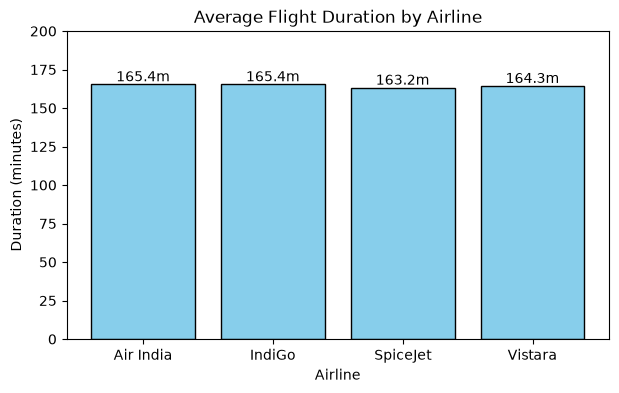

In [15]:
avg_duration = df_flights.groupby('airline')['duration_minutes'].mean().round(1).reset_index()
avg_duration['duration_hours'] = (avg_duration['duration_minutes'] / 60).round(1)
print(avg_duration)

# Simple bar chart
plt.figure(figsize=(7, 4))
plt.bar(avg_duration['airline'], avg_duration['duration_minutes'], color='skyblue', edgecolor='black')
plt.title('Average Flight Duration by Airline')
plt.xlabel('Airline')
plt.ylabel('Duration (minutes)')
for i, val in enumerate(avg_duration['duration_minutes']):
    plt.text(i, val + 2, f"{val}m", ha='center')
plt.ylim(0, 200)
plt.show()

**Observation:** Average duration is almost the same across all 4 airlines.

### KPI 2: Route-wise Traffic
Checking which routes have the most flights operated.

Top 10 Busiest Routes:
        route  flight_count
0  BOM -> CCU            90
1  CCU -> DEL            72
2  MAA -> BLR            65
3  BLR -> BOM            60
4  HYD -> MAA            57
5  DEL -> HYD            54
6  HYD -> DEL            42
7  BOM -> DEL            39
8  CCU -> BOM            33
9  DEL -> BLR            29


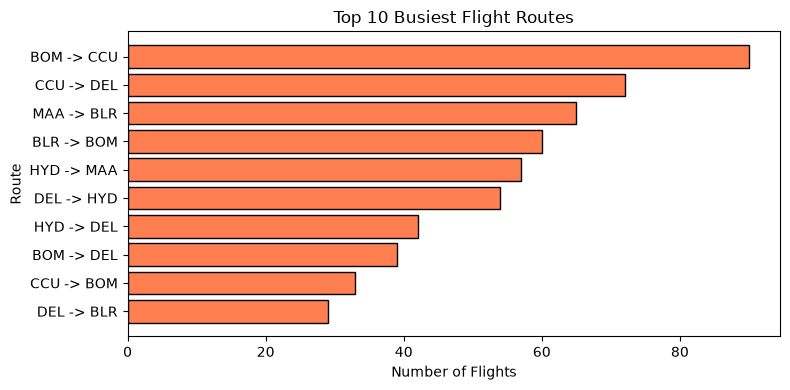

In [16]:
route_traffic = df_flights['route'].value_counts().reset_index()
route_traffic.columns = ['route', 'flight_count']
print("Top 10 Busiest Routes:")
print(route_traffic.head(10))

# Horizontal bar chart for top 10 routes
plt.figure(figsize=(8, 4))
top10 = route_traffic.head(10)
plt.barh(top10['route'][::-1], top10['flight_count'][::-1], color='coral', edgecolor='black')
plt.title('Top 10 Busiest Flight Routes')
plt.xlabel('Number of Flights')
plt.ylabel('Route')
plt.tight_layout()
plt.show()

**Observation:** BOM -> CCU is the busiest route with 90 flights, followed by CCU -> DEL with 72 flights.

### KPI 3: Delays / Anomalies
To find flights that took abnormally long compared to the usual time for that route.
I will calculate the average and standard deviation for each route, and flag any flight where duration > mean + 2 * std.

Number of delayed/anomaly flights found: 1


,flight_id,airline,route,duration_minutes,mean,threshold
506,6F212,IndiGo,BLR -> CCU,282.0,128.52381,278.990575


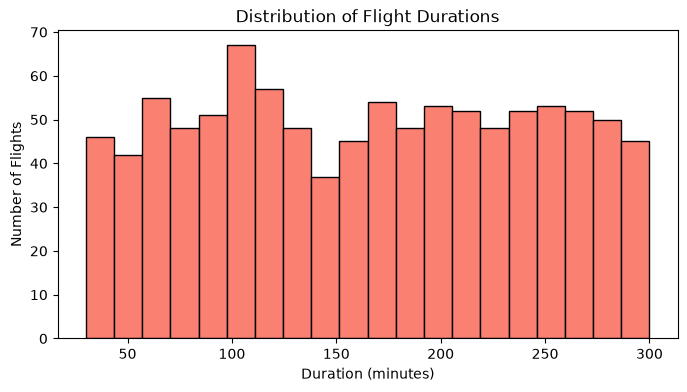

In [17]:
# Calculate route average and standard deviation
route_stats = df_flights.groupby('route')['duration_minutes'].agg(['mean', 'std']).reset_index()
route_stats['threshold'] = route_stats['mean'] + (2 * route_stats['std'])

# Merge with flights table to check which flights crossed the threshold
flights_check = df_flights.merge(route_stats, on='route', how='left')
flights_check['is_delayed_anomaly'] = flights_check['duration_minutes'] > flights_check['threshold']

anomalies = flights_check[flights_check['is_delayed_anomaly'] == True]
print(f"Number of delayed/anomaly flights found: {len(anomalies)}")
display(anomalies[['flight_id', 'airline', 'route', 'duration_minutes', 'mean', 'threshold']])

# Histogram of flight durations
plt.figure(figsize=(8, 4))
plt.hist(df_flights['duration_minutes'], bins=20, color='salmon', edgecolor='black')
plt.title('Distribution of Flight Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Flights')
plt.show()

**Observation:** After I already removed the negative duration error during data cleaning, only 1 flight crossed the 2-sigma threshold. Most flights falls between 30 and 300 minutes.

### KPI 4: Distribution of Flights by Airline
Checking how many flights each airline operates to see their market share.

airline
IndiGo       272
Air India    255
SpiceJet     246
Vistara      230
Name: count, dtype: int64


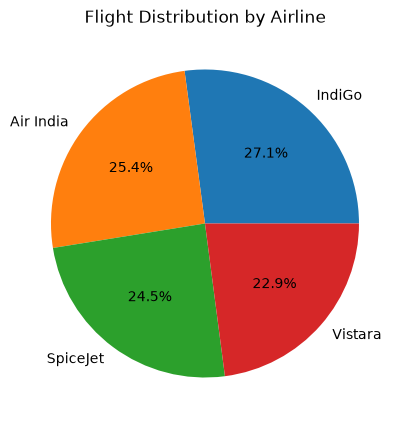

In [30]:
airline_counts = df_flights['airline'].value_counts()
print(airline_counts)

# Pie chart
plt.figure(figsize=(5, 5))
plt.pie(airline_counts, labels=airline_counts.index, autopct='%1.1f%%')
plt.title('Flight Distribution by Airline')
plt.show()

**Observation:** IndiGo has the highest share with 27.1%, followed by Air India (25.4%), SpiceJet (24.5%), and Vistara (22.9%).

### KPI 5: Booking Status Breakdown
Checking how many bookings are Confirmed, Cancelled, or Pending.

status
CANCELLED    344
CONFIRMED    320
PENDING      291
UNKNOWN       45
Name: count, dtype: int64


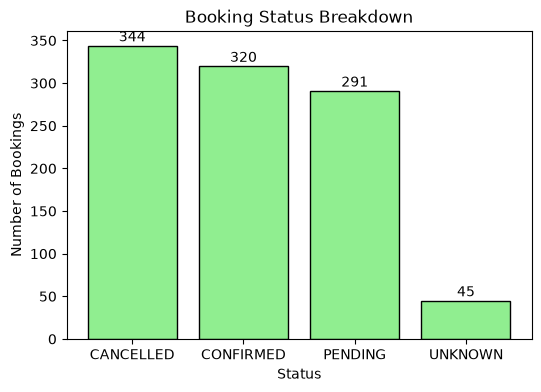

In [32]:
status_counts = df_bookings['status'].value_counts()
print(status_counts)

# Bar chart
plt.figure(figsize=(6, 4))
plt.bar(status_counts.index, status_counts.values, color='lightgreen', edgecolor='black')
plt.title('Booking Status Breakdown')
plt.xlabel('Status')
plt.ylabel('Number of Bookings')
for i, val in enumerate(status_counts.values):
    plt.text(i, val + 5, str(val), ha='center')
plt.show()

**Observation:** Cancelled bookings make up 34.4% (including the invalid bookings we replaced with cancelled), Confirmed bookings are 32.0%, and Pending bookings are 29.1%.

### KPI 6: Total Revenue by Airline
Using combined analytical table to sum payment amounts by airline (filtering out missing amounts).

     airline      amount
0    Vistara  2130804.88
1   SpiceJet  1899688.00
2  Air India  1719313.53
3     IndiGo  1620636.47


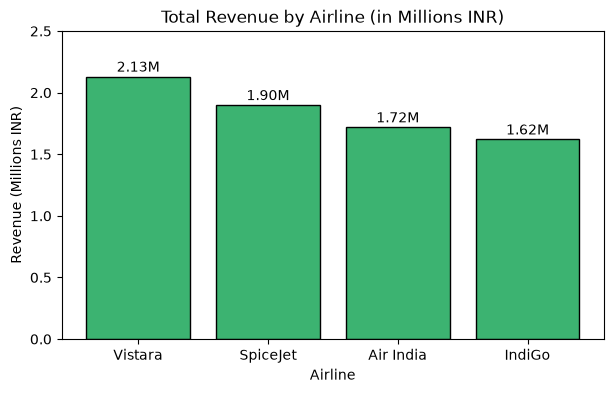

In [20]:
# Filter out records where payment amount is missing
valid_payments = df_analytical[df_analytical['is_amount_missing'] == False]

airline_revenue = valid_payments.groupby('airline')['amount'].sum().sort_values(ascending=False).reset_index()
print(airline_revenue)

# Bar chart in Millions INR
plt.figure(figsize=(7, 4))
plt.bar(airline_revenue['airline'], airline_revenue['amount'] / 1e6, color='mediumseagreen', edgecolor='black')
plt.title('Total Revenue by Airline (in Millions INR)')
plt.xlabel('Airline')
plt.ylabel('Revenue (Millions INR)')
for i, val in enumerate(airline_revenue['amount'] / 1e6):
    plt.text(i, val + 0.04, f"{val:.2f}M", ha='center')
plt.ylim(0, 2.5)
plt.show()

**Observation:** Vistara made the highest revenue (~2.13 Million INR) even though it operated fewer flights, because its ticket prices were higher on average. SpiceJet made 1.90M, Air India 1.72M, and IndiGo 1.62M.

### KPI 7: Top 5 Highest Revenue Routes
Checking which flight routes brought in the most money.

        route     amount
0  BOM -> CCU  700135.30
1  CCU -> DEL  582851.37
2  DEL -> HYD  521798.78
3  BLR -> BOM  506069.04
4  MAA -> BLR  492102.05


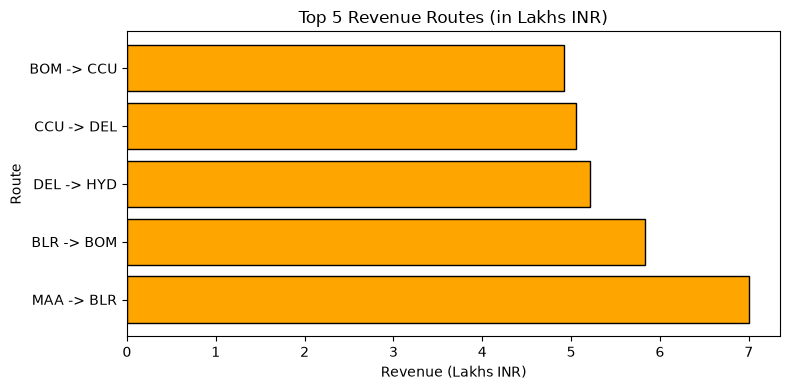

In [21]:
route_revenue = valid_payments.groupby('route')['amount'].sum().sort_values(ascending=False).head(5).reset_index()
print(route_revenue)

# Horizontal bar chart in Lakhs INR
plt.figure(figsize=(8, 4))
plt.barh(route_revenue['route'][::-1], route_revenue['amount'] / 1e5, color='orange', edgecolor='black')
plt.title('Top 5 Revenue Routes (in Lakhs INR)')
plt.xlabel('Revenue (Lakhs INR)')
plt.ylabel('Route')
plt.tight_layout()
plt.show()

**Observation:** The highest revenue routes match with the high traffic routes (like BOM -> CCU and CCU -> DEL), showing that frequency drives the overall revenue.